--- 1. Veri Yükleniyor ---
Orijinal Veri Boyutu: 7 satır.

--- 2. Veri Temizleme İşlemleri Başladı ---
Temizleme Sonrası Veri Boyutu: 5 satır.

--- 3. Analitik Segmentasyon Uygulanıyor ---
      ad  toplam_harcama                      Segment
0    Ali          1500.0      Potansiyel (Yeni/Aktif)
1   Ayse          4500.0   VIP (Yüksek Değer & Aktif)
4    Can          2200.0     Sadık (Geri Kazanılmalı)
5  Derya           800.0      Potansiyel (Yeni/Aktif)
6  Burak            50.0  Risk (Kaybedilme Olasılığı)

--- 4. Görsel Rapor Oluşturuluyor ---
İşlem Başarıyla Tamamlandı: Grafik ve CSV raporu hazır!


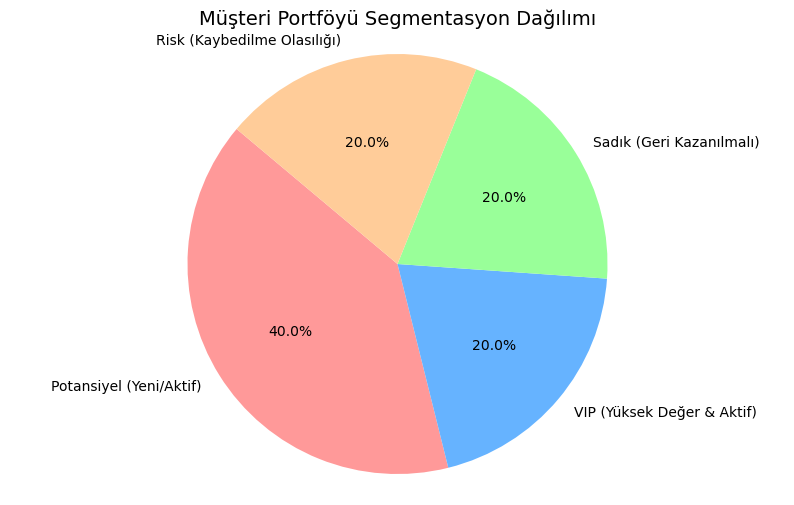

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# =================================================================
# GÜN 6: BÜYÜK VERİ ODAKLI MÜŞTERİ SEGMENTASYONU VE GÖRSELLEŞTİRME
# =================================================================

# 1. Simüle Edilmiş Kirli Veri Seti
raw_data = """musteri_id,ad,toplam_harcama,son_alisveris_tarihi,lokasyon
101,Ali,1500,2023-10-01,Istanbul
102,Ayse,4500,2023-10-03,Ankara
103,Mehmet,-200,2023-09-01,Izmir
104,Zeynep,NaN,2023-10-05,Istanbul
105,Can,2200,2023-08-15,Bursa
106,Derya,800,2023-10-04,Ankara
107,Burak,50,2023-05-01,Istanbul
"""

print("--- 1. Veri Yükleniyor ---")
df = pd.read_csv(io.StringIO(raw_data))
print(f"Orijinal Veri Boyutu: {len(df)} satır.\n")

# =================================================================
# 2. VERİ TEMİZLEME (DATA CLEANING)
# =================================================================
print("--- 2. Veri Temizleme İşlemleri Başladı ---")

# Tarih dönüşümü
df['son_alisveris_tarihi'] = pd.to_datetime(df['son_alisveris_tarihi'])

# NaN ve negatif harcamaların temizlenmesi
temiz_df = df.dropna(subset=['toplam_harcama']).copy()
temiz_df = temiz_df[temiz_df['toplam_harcama'] > 0]

# Recency (Pasif Gün Sayısı) Hesaplama
bugun = pd.to_datetime("2023-10-10")
temiz_df['pasif_gun_sayisi'] = (bugun - temiz_df['son_alisveris_tarihi']).dt.days

print(f"Temizleme Sonrası Veri Boyutu: {len(temiz_df)} satır.\n")

# =================================================================
# 3. ANALİTİK SEGMENTASYON (RFM LOGIC)
# =================================================================
print("--- 3. Analitik Segmentasyon Uygulanıyor ---")

def rfm_segment_olustur(row):
    harcama = row['toplam_harcama']
    pasiflik = row['pasif_gun_sayisi']
    
    if harcama > 2000 and pasiflik < 30:
        return "VIP (Yüksek Değer & Aktif)"
    elif harcama > 2000 and pasiflik >= 30:
        return "Sadık (Geri Kazanılmalı)"
    elif harcama <= 2000 and pasiflik < 15:
        return "Potansiyel (Yeni/Aktif)"
    else:
        return "Risk (Kaybedilme Olasılığı)"

temiz_df['Segment'] = temiz_df.apply(rfm_segment_olustur, axis=1)
print(temiz_df[['ad', 'toplam_harcama', 'Segment']].head())

# =================================================================
# 4. RAPORLAMA VE GÖRSELLEŞTİRME
# =================================================================
print("\n--- 4. Görsel Rapor Oluşturuluyor ---")

segment_counts = temiz_df['Segment'].value_counts()

plt.figure(figsize=(10, 6))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Müşteri Portföyü Segmentasyon Dağılımı', fontsize=14)
plt.axis('equal')

# Çıktıları Kaydetme
plt.savefig("musteri_segmentasyonu_grafik.png")
temiz_df.to_csv("stratejik_musteri_analizi.csv", index=False)

print("İşlem Başarıyla Tamamlandı: Grafik ve CSV raporu hazır!")